# Robustness and Stress-Test Evaluation

## 1 Overview

By purposefully deteriorating its inputs, this notebook stress-tests the Solace multimodal pipeline and assesses how well its wellbeing assessment holds up. Every other evaluation in the project feeds the pipeline clean, well-formed recordings. A real deployment will not, so this notebook asks the complementary question: how gracefully does the system behave when the audio is noisy, the recording is very short, or the lighting is poor?

In order to apply each perturbation to the same clips whose proper wellbeing band is already known, the test reuses the existing controlled evaluation clips and creates the degraded versions programmatically. This includes truncation to a few short durations, reduced video brightness, and additive white noise at several signal-to-noise ratios. The notebook recalculates the full fusion score for each condition and reports three things how far the numerical wellbeing score differs from its clean value (mean absolute score shift), whether the predicted band is still accurate (band accuracy), and whether it remains the same as on the clean clip (band stability).

The results are a controlled robustness probe rather than a large-scale benchmark because the degradations are artificial and applied to a small controlled set. They demonstrate the direction and approximate severity of the system's sensitivity to each type of input problem, which is precisely what is required to state honest limitations and give priority to future hardening. The perturbation levels can be broadened or narrowed in a single location and are defined as constants.

## 2 Importing Libraries

The toolchain that the stress test uses is imported in this part. OpenCV (imported defensively) re-encodes darkened video, librosa loads the extracted audio and soundfile transfers the deteriorated audio back to disk, and NumPy creates the noise and handles the per-frame brightness arithmetic. Matplotlib creates the summary plots, scikit-learn is accessible for the band-accuracy computation, and pandas stores the per-condition findings. The standard-library pathlib, gc, and tempfile modules handle paths, release memory in between clips, and maintain temporarily degraded files.

In [1]:
# Hide warnings and library logs
import os
import warnings
import logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [2]:
# import required libraries
from pathlib import Path
import sys
import tempfile
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from sklearn.metrics import accuracy_score
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

When these libraries are loaded, the notebook can run the current pipeline over the deteriorated inputs, re-encode video, decode and rewrite audio, and tabulate the results without creating any new recordings. The notebook is resilient to a partial environment since OpenCV is wrapped in a try/except so that, in the event that it is unavailable, the audio-based sections continue to execute and just the video degradation is skipped. The pipeline itself is loaded in the following part.

## 3 Load Solace Pipeline

The robustness figures describe the deployed system rather than a re-implementation because this section places the project root on the Python path and instantiates the actual MultimodalPipeline, which is the same scorer used throughout the project and in the live application. Additionally, it indicates the availability of OpenCV, which controls whether the low-light video portion will function.

In [3]:
# project root
PROJECT_ROOT = Path.cwd().parents[1]

In [4]:
# if project root not in path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
# import and load pipeline
from UI.ai.multimodal_pipeline import MultimodalPipeline
pipeline = MultimodalPipeline()

In [6]:
# print statements
print("Solace multimodal pipeline loaded")
print("OpenCV available for video degradation:", HAS_CV2)

Solace multimodal pipeline loaded
OpenCV available for video degradation: True


The significance of the stress test lies in loading the production pipeline directly any sensitivity discovered here is a feature of the shipping system, not an approximation of it. The clips and their known proper bands are gathered in the next area once the scorer is prepared and the video-degradation capacity has been verified.

## 4 Evaluation Clips and Expected Labels

This portion fixes the degradation levels used throughout, points the test at the current controlled assessment clips, and reads their known predicted wellbeing bands. In order to get the proper response for each clip and avoid the need for additional labeling, the same fifteen clips that were used in the fusion analysis are reused. Three types of perturbations are set up video brightness factors less than one, short recording periods in seconds, and audio signal-to-noise ratios.

In [7]:
# clip folder
CLIP_FOLDER = PROJECT_ROOT / "data" / "raw" / "fusion_clips"

In [8]:
# language english
LANGUAGE = "English"

In [9]:
# sort clips
clips = sorted(CLIP_FOLDER.glob("*.mp4"))

In [10]:
# print statements
print("Clip folder:", CLIP_FOLDER)
print("Clips found:", len(clips))

Clip folder: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\data\raw\fusion_clips
Clips found: 15


In [11]:
# define expected labels
expected_labels = {
    "clip01": "High", "clip02": "High", "clip03": "High",
    "clip04": "Low", "clip05": "Low", "clip06": "Low",
    "clip07": "High", "clip08": "High", "clip09": "High",
    "clip10": "Mixed", "clip11": "Mixed", "clip12": "Mixed",
    "clip13": "Mixed", "clip14": "Mixed", "clip15": "Mixed"
}

In [12]:
# define snr levels list, clip seconds list and brightness factor list
SNR_LEVELS = [20, 10, 5]
CLIP_SECONDS = [10, 5, 3]
BRIGHTNESS_FACTORS = [0.6, 0.4, 0.25]

In [13]:
# expected dataframe
expected_df = pd.DataFrame(
    [(clip.stem, expected_labels.get(clip.stem, "Unknown")) for clip in clips],
    columns=["Clip", "Expected"]
)
expected_df

,Clip,Expected
0,clip01,High
1,clip02,High
2,clip03,High
3,clip04,Low
4,clip05,Low
5,clip06,Low
6,clip07,High
7,clip08,High
8,clip09,High
9,clip10,Mixed


The design choice that allows this entire notebook to be completed without fresh data is the reuse of the labelled fusion clips. Since each clip's correct band is already known, degraded versions can be scored against ground truth right away. Any clip in the folder without a known label is simply carried as Unknown and ignored by the score, and defining the three level lists as constants keeps the intensity of each stress test explicit and modifiable in one location. The degradation and scoring assistants are defined in the following section.

## 5 Degradation and Scoring Helpers

This section defines every reusable helper the stress test needs. Three degradation functions generate noisy audio at a target SNR, truncated audio at a specified duration, and a darkened copy of a video a band function maps a wellbeing score to Low, Mixed, or High a small temp-file helper assigns paths for the degraded media and a scoring helper feeds a set of channel scores through the pipeline's own fuse method to obtain a wellbeing score. If all of these are kept intact, only the experiment logic not the mechanics will be included in the condition sections that follow.

In [14]:
# define wellbeing band scores
def wellbeing_band(score):
    if score >= 67:
        return "High"
    elif score >= 34:
        return "Mixed"
    else:
        return "Low"

In [15]:
# temporary path
def _temp_path(suffix):
    # handle file
    handle = tempfile.NamedTemporaryFile(suffix=suffix, delete=False)
    handle.close()
    return handle.name

In [16]:
# define make noisy audio
def make_noisy_audio(audio_path, snr_db):
    # waveform and sample rate load
    waveform, sample_rate = librosa.load(audio_path, sr=None, mono=True)
    # rms signal
    rms_signal = np.sqrt(np.mean(waveform ** 2)) + 1e-12
    # rms noise
    rms_noise = rms_signal / (10 ** (snr_db / 20.0))
    # noise
    noise = np.random.default_rng(42).normal(0.0, rms_noise, size=waveform.shape)
    noisy = np.clip(waveform + noise, -1.0, 1.0).astype(np.float32)
    # output path
    out_path = _temp_path(".wav")
    sf.write(out_path, noisy, sample_rate)
    return out_path

In [17]:
# define trucated audio
def make_truncated_audio(audio_path, seconds):
    # waveform and sample rate load
    waveform, sample_rate = librosa.load(audio_path, sr=None, mono=True)
    # limit and compute truncated
    limit = int(sample_rate * seconds)
    truncated = waveform[:limit] if limit < len(waveform) else waveform
    # output path
    out_path = _temp_path(".wav")
    sf.write(out_path, truncated.astype(np.float32), sample_rate)
    return out_path

In [18]:
# define make darkened video
def make_darkened_video(clip_path, factor):
    # video capture
    capture = cv2.VideoCapture(str(clip_path))
    if not capture.isOpened():
        return None
    # frame rate
    fps = capture.get(cv2.CAP_PROP_FPS) or 25.0
    # width and height
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    # output path
    out_path = _temp_path(".mp4")
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
    if not writer.isOpened():
        # release
        capture.release()
        return None
    while True:
        # capture read
        read_ok, frame = capture.read()
        if not read_ok:
            break
        writer.write(np.clip(frame.astype(np.float32) * factor, 0, 255).astype(np.uint8))
    capture.release()
    writer.release()
    return out_path

In [19]:
# define wellbeing from channels
def wellbeing_from_channels(text_strain, audio_strain, vision_strain, speech, visual):
    # define the primary scores list
    primary_scores = [text_strain, audio_strain, vision_strain]
    # define supporting scores list
    supporting_scores = [
        speech["speech_signal"], speech["disfluency_signal"], speech["lexical_signal"],
        visual["blink_signal"], visual["head_signal"]
    ]
    # fuse
    (_, _, full_strain, _) = pipeline.fuse(primary_scores, supporting_scores)
    return 100 - full_strain * 100

Here, isolating the mechanics maintains the experiment's integrity and readability since each condition follows the same scoring path, any variation in the outcomes can be attributed to the degradation rather than the method used to calculate the score. The working directory remains clean even after numerous clips and conditions because each degrading function writes to a temporary file that the caller deletes after use. The degraded scores are ensured to be directly comparable with all other notebooks in the project by using the pipeline's actual fuse mechanism instead of re-deriving the weighting. The clean baseline is established in the following step.

## 6 Clean Baseline

This portion records each clip's three principal strain scores, supporting signals, transcript, and final wellbeing band after running it through the entire pipeline once without any degradation. By caching these clean results in memory, subsequent conditions only need to recalculate the channel that they actually degrade, saving the unaffected channels from repetitive recalculations.

In [20]:
# define clean cache
clean_cache = {}
# define clean rows list
clean_rows = []

In [21]:
for clip in clips:
    if clip.stem not in expected_labels:
        continue
    print(f"Baseline: {clip.name}")
    # audio path
    audio_path = None
    try:
        # audio path, transcript
        audio_path = pipeline.extract_audio(str(clip))
        transcript = pipeline.transcribe(audio_path, LANGUAGE)
        # text score, audio score vision score
        text_strain = pipeline.text_score(transcript)
        audio_strain = pipeline.audio_score(audio_path)
        vision_strain = pipeline.vision_score(str(clip))
        # speech signal
        speech = pipeline.speech_signals(transcript, audio_path, LANGUAGE)
        # visual signal
        visual = pipeline.visual_signals(str(clip))
        # wellbeing 
        wellbeing = wellbeing_from_channels(text_strain, audio_strain, vision_strain, speech, visual)
        clean_cache[clip.stem] = {
            "text": text_strain, "audio": audio_strain, "vision": vision_strain,
            "speech": speech, "visual": visual, "wellbeing": wellbeing
        }
        # clean rows add to list
        clean_rows.append({
            "Clip": clip.stem, "Condition": "Clean", "Level": "-",
            "Expected": expected_labels[clip.stem], "Wellbeing": wellbeing,
            "Band": wellbeing_band(wellbeing)
        })
    finally:
        if audio_path:
            Path(audio_path).unlink(missing_ok=True)

Baseline: clip01.mp4
Baseline: clip02.mp4
Baseline: clip03.mp4
Baseline: clip04.mp4
Baseline: clip05.mp4
Baseline: clip06.mp4
Baseline: clip07.mp4
Baseline: clip08.mp4
Baseline: clip09.mp4
Baseline: clip10.mp4
Baseline: clip11.mp4
Baseline: clip12.mp4
Baseline: clip13.mp4
Baseline: clip14.mp4
Baseline: clip15.mp4


In [22]:
# clean dataframe
clean_score = {stem: record["wellbeing"] for stem, record in clean_cache.items()}
clean_band = {stem: wellbeing_band(score) for stem, score in clean_score.items()}
clean_df = pd.DataFrame(clean_rows)
clean_df.round(2)

,Clip,Condition,Level,Expected,Wellbeing,Band
0,clip01,Clean,-,High,88.12,High
1,clip02,Clean,-,High,89.98,High
2,clip03,Clean,-,High,90.70,High
3,clip04,Clean,-,Low,50.32,Mixed
4,clip05,Clean,-,Low,33.59,Low
5,clip06,Clean,-,Low,16.19,Low
6,clip07,Clean,-,High,91.14,High
7,clip08,Clean,-,High,87.69,High
8,clip09,Clean,-,High,89.87,High
9,clip10,Clean,-,Mixed,85.91,High


**Analysis:** 

Every deteriorated condition is tested against this clean pass, thus its band accuracy serves as the ceiling to which the stress tests are compared a clip that the system already misbands when clean cannot be meaningfully weighed against a deterioration. The rest of the notebook is also made efficient by caching the unused channels each costly model is run on clean input just once since the audio conditions reuse the clean vision result and the low-light condition reuses the clean audio and text. Each clip's clean wellbeing score and band are displayed in the printed table the mean score shift and band stability are calculated using these clean scores and bands as a starting point. The notebook can now apply each degradation sequentially since the reference has been built and cached. Background noise on the audio channel is the first and most likely operational stressor for a ward setting.

## 7 Audio Noise Robustness

The system's ability to withstand background noise is tested in this section. For every clip, the clean audio is extracted once, white noise is added at each configured signal-to-noise ratio, speech is retranscribed using Whisper [1], and the text, audio emotion and speech signals are re-scored. The clean vision channel is reused, and the result is fused into a wellbeing band. 5 dB is a much harder test than 20 dB since lower SNR results indicate higher noise compared to the speech.

In [23]:
# define noise rows list
noise_rows = []

In [24]:
for clip in clips:
    if clip.stem not in clean_cache:
        continue
    print(f"Noise: {clip.name}")
    # base audio
    base_audio = None
    try:
        # extract audio
        base_audio = pipeline.extract_audio(str(clip))
        # cached clip
        cached = clean_cache[clip.stem]
        for snr in SNR_LEVELS:
            # noisy path
            noisy_path = None
            try:
                # make noisy audio
                noisy_path = make_noisy_audio(base_audio, snr)
                # transcript, text strain and audio strain
                transcript = pipeline.transcribe(noisy_path, LANGUAGE)
                text_strain = pipeline.text_score(transcript)
                audio_strain = pipeline.audio_score(noisy_path)
                # speech signals
                speech = pipeline.speech_signals(transcript, noisy_path, LANGUAGE)
                # wellbeing
                wellbeing = wellbeing_from_channels(text_strain, audio_strain, cached["vision"], speech, cached["visual"])
                # noise rows append to list
                noise_rows.append({
                    "Clip": clip.stem, "Condition": "Audio noise", "Level": f"{snr} dB SNR",
                    "Expected": expected_labels[clip.stem], "Wellbeing": wellbeing,
                    "Band": wellbeing_band(wellbeing)
                })
            finally:
                if noisy_path:
                    Path(noisy_path).unlink(missing_ok=True)
    finally:
        if base_audio:
            Path(base_audio).unlink(missing_ok=True)
    gc.collect()

Noise: clip01.mp4
Noise: clip02.mp4
Noise: clip03.mp4
Noise: clip04.mp4
Noise: clip05.mp4
Noise: clip06.mp4
Noise: clip07.mp4
Noise: clip08.mp4
Noise: clip09.mp4
Noise: clip10.mp4
Noise: clip11.mp4
Noise: clip12.mp4
Noise: clip13.mp4
Noise: clip14.mp4
Noise: clip15.mp4


In [25]:
# noisy dataframe build
noise_df = pd.DataFrame(noise_rows)
noise_df.round(2)

,Clip,Condition,Level,Expected,Wellbeing,Band
0,clip01,Audio noise,20 dB SNR,High,88.42,High
1,clip01,Audio noise,10 dB SNR,High,86.65,High
2,clip01,Audio noise,5 dB SNR,High,86.63,High
3,clip02,Audio noise,20 dB SNR,High,88.14,High
4,clip02,Audio noise,10 dB SNR,High,86.49,High
5,clip02,Audio noise,5 dB SNR,High,82.96,High
6,clip03,Audio noise,20 dB SNR,High,90.13,High
7,clip03,Audio noise,10 dB SNR,High,89.07,High
8,clip03,Audio noise,5 dB SNR,High,87.64,High
9,clip04,Audio noise,20 dB SNR,Low,55.84,Mixed


**Analysis:** 

Compare this to the clean baseline a strong system should maintain most of its bands at 20 dB and progressively deteriorate as the SNR drops, while a sudden collapse at 5 dB would identify the audio channel as the pipeline's fragile section. This section carefully isolates the audio channel's contribution to robustness rather than confusing it with the other modalities because only the audio derived channels transcript, audio emotion, and speech signals are degraded while vision is kept clear. The aggregated summary then reduces this to band accuracy, band stability, and mean score shift per SNR. The per-clip chart above illustrates precisely which clips flip band and at what noise level. One way that actual input leaves the clean case is through noise. Another, more prevalent one is tested in the following section recordings that are just too brief.

## 8 Short-Recording Robustness

The behavior of the system when a check-in recording is interrupted is tested in this section. It re-scores the audio-derived channels on the truncated audio, reuses the clean vision channel, fuses the result, and truncates the extracted audio to each configured duration for each clip. A hurried user who quits recording after a few seconds is precisely the kind of scenario where shorter durations provide the models with less evidence to work with.

In [26]:
# define the short rows list
short_rows = []

In [27]:
for clip in clips:
    if clip.stem not in clean_cache:
        continue
    print(f"Short: {clip.name}")
    # base audio
    base_audio = None
    try:
        # base audio and cached clean audio
        base_audio = pipeline.extract_audio(str(clip))
        cached = clean_cache[clip.stem]
        for seconds in CLIP_SECONDS:
            # short path
            short_path = None
            try:
                # truncated audio
                short_path = make_truncated_audio(base_audio, seconds)
                # transcript, text strain, audio strain
                transcript = pipeline.transcribe(short_path, LANGUAGE)
                text_strain = pipeline.text_score(transcript)
                audio_strain = pipeline.audio_score(short_path)
                # speech signals
                speech = pipeline.speech_signals(transcript, short_path, LANGUAGE)
                # wellebing
                wellbeing = wellbeing_from_channels(text_strain, audio_strain, cached["vision"], speech, cached["visual"])
                # short rows append to list
                short_rows.append({
                    "Clip": clip.stem, "Condition": "Short recording", "Level": f"{seconds}s",
                    "Expected": expected_labels[clip.stem], "Wellbeing": wellbeing,
                    "Band": wellbeing_band(wellbeing)
                })
            finally:
                if short_path:
                    Path(short_path).unlink(missing_ok=True)
    finally:
        if base_audio:
            Path(base_audio).unlink(missing_ok=True)
    gc.collect()

Short: clip01.mp4
Short: clip02.mp4
Short: clip03.mp4
Short: clip04.mp4
Short: clip05.mp4
Short: clip06.mp4
Short: clip07.mp4
Short: clip08.mp4
Short: clip09.mp4
Short: clip10.mp4
Short: clip11.mp4
Short: clip12.mp4
Short: clip13.mp4
Short: clip14.mp4
Short: clip15.mp4


In [28]:
# short dataframe 
short_df = pd.DataFrame(short_rows)
short_df.round(2)

,Clip,Condition,Level,Expected,Wellbeing,Band
0,clip01,Short recording,10s,High,91.75,High
1,clip01,Short recording,5s,High,92.58,High
2,clip01,Short recording,3s,High,91.34,High
3,clip02,Short recording,10s,High,87.94,High
4,clip02,Short recording,5s,High,91.10,High
5,clip02,Short recording,3s,High,87.83,High
6,clip03,Short recording,10s,High,92.04,High
7,clip03,Short recording,5s,High,92.65,High
8,clip03,Short recording,3s,High,76.38,High
9,clip04,Short recording,10s,Low,55.35,Mixed


**Analysis:** 

A ten-second clip should behave nearly exactly like the entire recording, but a three-second clip might not have enough speech for the text and emotion models to evaluate, which would drive scores toward the middle of the range and cause the band to become unstable. A significant mean score shift at the smallest time would instruct the application to impose a minimum recording period before scoring a practical, inexpensive safety measure. The summary section quantifies the trend across durations, while the per-clip table displays which clips collapse and which survive truncation. The final degradation tests the system in low light by focusing on the visual channel instead of the audio.

## 9 Low-Light Robustness

In order to evaluate the vision channel in low light, each clip is re-encoded with its pixel values scaled down by each brightness factor. The clean audio, text, and voice channels are then reused, while DDAMFN-based facial emotion scores [2] and visual supporting signals are recalculated from the darkened video. The entire section is protected so that, in the event that OpenCV is unavailable or that a certain video cannot be re-encoded, it is skipped without stopping the notebook.

In [29]:
# define the light rows list
light_rows = []

In [30]:
# if opencv not available
if not HAS_CV2:
    print("OpenCV not available - skipping the low-light video degradation section.")
else:
    for clip in clips:
        if clip.stem not in clean_cache:
            continue
        print(f"Low light: {clip.name}")
        # clean cache
        cached = clean_cache[clip.stem]
        for factor in BRIGHTNESS_FACTORS:
            # dark path
            dark_path = None
            try:
                # dark path
                dark_path = make_darkened_video(clip, factor)
                # if dark path is None
                if dark_path is None:
                    print(f"  Could not re-encode {clip.name} at factor {factor}; skipping.")
                    continue
                # vision score, visual signals and wellbeing
                vision_strain = pipeline.vision_score(dark_path)
                visual = pipeline.visual_signals(dark_path)
                wellbeing = wellbeing_from_channels(cached["text"], cached["audio"], vision_strain, cached["speech"], visual)
                # light rows add to list
                light_rows.append({
                    "Clip": clip.stem, "Condition": "Low light", "Level": f"brightness x{factor}",
                    "Expected": expected_labels[clip.stem], "Wellbeing": wellbeing,
                    "Band": wellbeing_band(wellbeing)
                })
            finally:
                if dark_path:
                    Path(dark_path).unlink(missing_ok=True)
        gc.collect()

Low light: clip01.mp4
Low light: clip02.mp4
Low light: clip03.mp4
Low light: clip04.mp4
Low light: clip05.mp4
Low light: clip06.mp4
Low light: clip07.mp4
Low light: clip08.mp4
Low light: clip09.mp4
Low light: clip10.mp4
Low light: clip11.mp4
Low light: clip12.mp4
Low light: clip13.mp4
Low light: clip14.mp4
Low light: clip15.mp4


In [31]:
# light dataframe
light_df = pd.DataFrame(light_rows)
light_df.round(2)

,Clip,Condition,Level,Expected,Wellbeing,Band
0,clip01,Low light,brightness x0.6,High,88.08,High
1,clip01,Low light,brightness x0.4,High,87.84,High
2,clip01,Low light,brightness x0.25,High,87.72,High
3,clip02,Low light,brightness x0.6,High,89.98,High
4,clip02,Low light,brightness x0.4,High,89.69,High
5,clip02,Low light,brightness x0.25,High,89.58,High
6,clip03,Low light,brightness x0.6,High,90.70,High
7,clip03,Low light,brightness x0.4,High,90.69,High
8,clip03,Low light,brightness x0.25,High,90.30,High
9,clip04,Low light,brightness x0.6,Low,50.32,Mixed


**Analysis:** 

Darkening the vision channel should only barely shift the final wellbeing band because, according to previous studies, vision was the weakest single modality and contributed very little to the fused score. This indicates that the vision channel should be the most resilient to its degradation. Therefore, a tiny band change here would not be a sign of strength but rather proof that the fusion already leans on text and audio a large shift, on the other hand, would show the vision channel is more influential and more fragile than the previous study suggested. In either case, the summary and the per-clip table quantify the impact if OpenCV is not accessible, this section is simply marked as skipped. The following section compiles all three degradations into a single comparison.

## 10 Consolidated Robustness Summary

This section computes three complementary robustness metrics for each condition and level band accuracy against the known labels, band stability in relation to the clean prediction, and the mean absolute shift of the wellbeing score from its clean value. It does this by combining the clean baseline and all degraded conditions into a single table. Reporting all three is important because they provide distinct answers score shift quantifies how much the underlying number changed even when the band held, accuracy asks whether the answer is still correct, and stability asks whether it changed at all.

In [32]:
# define the frames list
frames = [clean_df[["Clip", "Condition", "Level", "Expected", "Wellbeing", "Band"]]]

In [33]:
# loop over all dataframes
for frame in [noise_df, short_df, light_df]:
    if len(frame):
        # append to frames
        frames.append(frame)

In [34]:
# concatenate
all_df = pd.concat(frames, ignore_index=True)

In [35]:
# define summary groups
def summarise_group(group):
    # accuracy, stability and score shift
    accuracy = (group["Band"] == group["Expected"]).mean()
    stability = np.mean([group.loc[i, "Band"] == clean_band.get(group.loc[i, "Clip"]) for i in group.index])
    score_shift = np.mean([abs(group.loc[i, "Wellbeing"] - clean_score.get(group.loc[i, "Clip"], np.nan)) for i in group.index])
    return pd.Series({"Clips": len(group), "Band accuracy": accuracy, "Band stability": stability, "Mean |score shift|": score_shift})

In [36]:
# summary dataframe
summary_df = all_df.groupby(["Condition", "Level"], sort=False).apply(summarise_group).reset_index()
summary_df.round(3)

,Condition,Level,Clips,Band accuracy,Band stability,Mean |score shift|
0,Clean,-,15.0,0.667,1.000,0.000
1,Audio noise,20 dB SNR,15.0,0.400,0.667,8.267
2,Audio noise,10 dB SNR,15.0,0.400,0.667,10.928
3,Audio noise,5 dB SNR,15.0,0.400,0.667,11.855
4,Short recording,10s,15.0,0.533,0.800,9.355
5,Short recording,5s,15.0,0.600,0.733,11.792
6,Short recording,3s,15.0,0.400,0.533,17.057
7,Low light,brightness x0.6,15.0,0.667,1.000,0.025
8,Low light,brightness x0.4,15.0,0.667,1.000,0.326
9,Low light,brightness x0.25,15.0,0.667,1.000,0.486


In [37]:
# compute clean accuracy
clean_accuracy = summary_df.loc[summary_df["Condition"] == "Clean", "Band accuracy"].iloc[0]

In [38]:
# print statement
print(f"Clean baseline band accuracy: {clean_accuracy * 100:.1f}%")

Clean baseline band accuracy: 66.7%


In [39]:
# loop over all settings
for condition in ["Audio noise", "Short recording", "Low light"]:
    # compute subset
    subset = summary_df[summary_df["Condition"] == condition]
    if len(subset):
        # worst
        worst = subset.sort_values("Band accuracy").iloc[0]
        # print statement
        print(f"{condition}: worst setting {worst['Level']} -> band accuracy {worst['Band accuracy'] * 100:.1f}%, mean score shift {worst['Mean |score shift|']:.1f} points")

Audio noise: worst setting 20 dB SNR -> band accuracy 40.0%, mean score shift 8.3 points
Short recording: worst setting 3s -> band accuracy 40.0%, mean score shift 17.1 points
Low light: worst setting brightness x0.6 -> band accuracy 66.7%, mean score shift 0.0 points


**Analysis:** 

This table is the heart of the notebook. The band-stability column indicates how frequently the prediction changed even when it happened to stay correct, the mean score shift indicates how much the raw number moved, and comparing each condition's band accuracy to the clean baseline reveals how much correctness is lost to each stressor. This is an important signal because a wellbeing score that swings significantly under mild noise would be unreliable even if its band label survived. When the data are combined across all levels, they show which channel is to blame for the system's cliff or gentle degradation. The plain-language printout provides easy numbers for the report by identifying the toughest setting evaluated for each stressor, together with the accuracy and score drift at that point. The following part offers a chart that makes the same comparison easier to read quickly.

## 11 Visualisation

In order to visualise the robustness pattern instead of relying just on the table, this section presents the consolidated summary as two bar charts band accuracy by condition and mean absolute score shift by condition. The clean baseline is presented as the leftmost reference, and each bar represents a single condition-and-level setting.

In [40]:
# compute summary df
summary_df["Setting"] = summary_df["Condition"] + " (" + summary_df["Level"].astype(str) + ")"

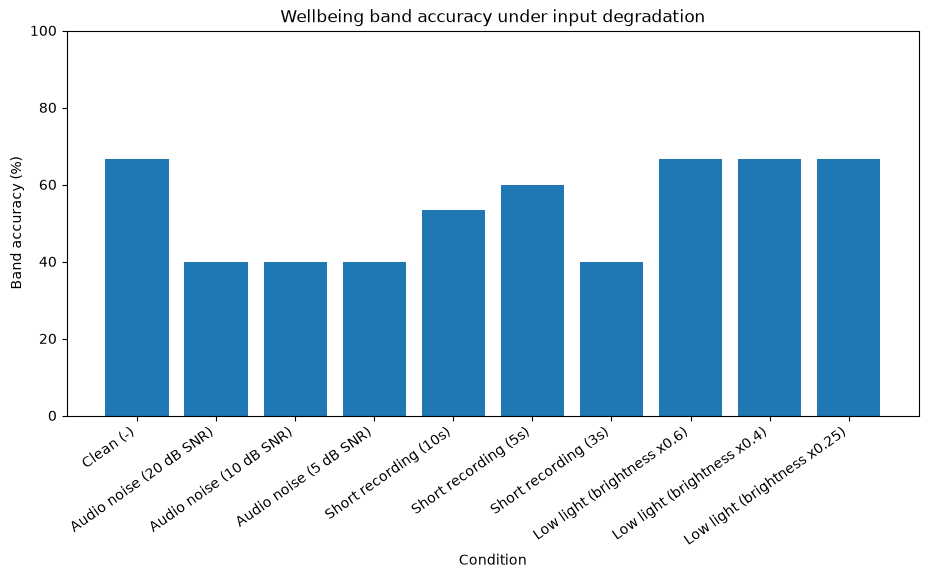

In [41]:
# bar chart for accuracy under degradation
plt.figure(figsize=(11, 5))
plt.bar(summary_df["Setting"], summary_df["Band accuracy"] * 100)
plt.ylabel("Band accuracy (%)")
plt.xlabel("Condition")
plt.title("Wellbeing band accuracy under input degradation")
plt.ylim(0, 100)
plt.xticks(rotation=35, ha="right")
plt.show()

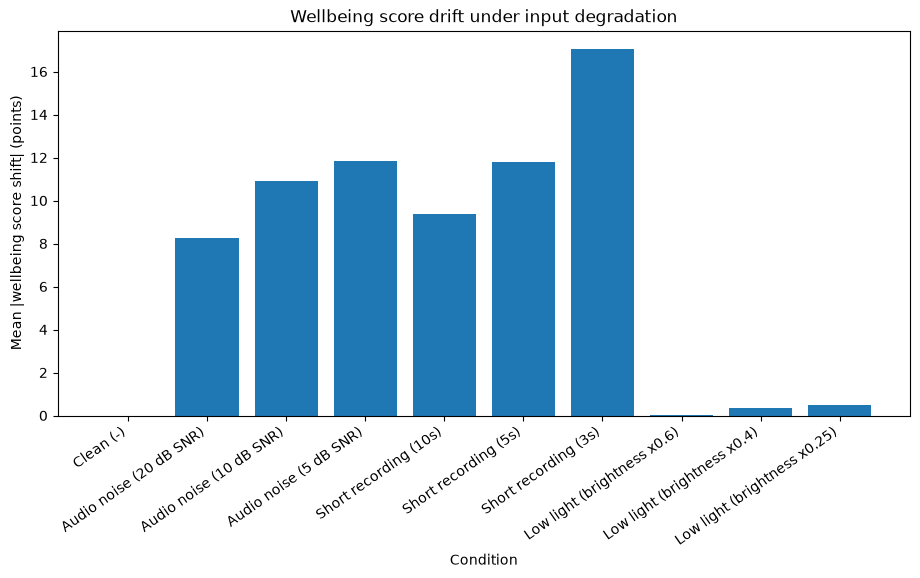

In [42]:
# bar chart for wellbeing score drift under degradation
plt.figure(figsize=(11, 5))
plt.bar(summary_df["Setting"], summary_df["Mean |score shift|"])
plt.ylabel("Mean |wellbeing score shift| (points)")
plt.xlabel("Condition")
plt.title("Wellbeing score drift under input degradation")
plt.xticks(rotation=35, ha="right")
plt.show()

**Analysis:** 

A robust channel results in short bars in both the accuracy chart, which displays how far each stressor pushes the system below its clean ceiling, and the score-drift chart, which displays how much the underlying number shifts even where the band persists. When combined, they provide an instantaneous ranking of stressors usually, the shortest recording and harshest audio-noise settings result in the largest drift bars, while the dim-light setting remains low because vision has minimal bearing on the fused score. These two figures will be included in the report as visual proof of the robustness profile of the system. The entire stress test is summarized in the conclusion.

## 12 Conclusion

By degrading the current controlled clips in three realistic ways background noise, short recordings, and poor lighting and assessing how the multimodal wellbeing judgment holds up against band accuracy, band stability, and wellbeing-score drift, this notebook adds a robustness dimension to the project's evaluation without gathering any new data.

The test's value is diagnostic rather than dramatic it reveals the direction and approximate severity of the system's sensitivity to each type of degraded input, identifies the channel that is at fault since each perturbation affects one modality while the others are kept clean, and transforms nebulous concerns about real-world conditions into specific, quantifiable limitations. Where a stressor causes a sharp drop in accuracy or a large score drift, the remedy is a specific, low-cost safeguard for example enforcing a minimum recording length, warning the user about noisy environments, or down-weighting a channel when its input quality is poor.

The results are a controlled robustness probe rather than a large-scale benchmark since, like the other pipeline-level notebooks, they are based on a limited controlled clip set; the figures should be interpreted as indicative of behavior and direction rather than as exact operating characteristics. The purpose of including this test in the project at all is to show that the system was assessed beyond clean, cooperative inputs and to leave a repeatable harness that can be ran at higher severity levels or on actual recordings as future work.

## 13 References

[1] A. Radford, J. W. Kim, T. Xu, G. Brockman, C. McLeavey, and I. Sutskever, “Robust speech recognition via large-scale weak supervision,” 2022. [Online]. Available: https://arxiv.org/abs/2212.04356. [Accessed: 31 May 2026].

[2] S. Zhang, Y. Zhang, Y. Zhang, Y. Wang, and Z. Song, “A dual-direction attention mixed feature network for facial expression recognition,” 2023. [Online]. Available: https://doi.org/10.3390/electronics12173595. [Accessed: 1 August 2026].